In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Task - 1 Web scrapping

● Use Python libraries like BeautifulSoup or Scrapy to extract data from websites.
● Identify and collect relevant datasets from public web pages.
● If you don’t code, use automated tools like Octoparse or ParseHub.
● Learn to handle HTML structure and web navigation to gather accurate data.
● Create custom datasets tailored to specific analysis needs.

In [5]:
# Python libraries for web scraping
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [6]:
# How Python accesses a webpage
url = "https://books.toscrape.com/"
response = requests.get(url)
print(response.status_code)

200


In [7]:
# How to read/parse HTML
soup = BeautifulSoup(response.text,"html.parser")
print(soup.title)

<title>
    All products | Books to Scrape - Sandbox
</title>


In [8]:
# How to locate HTML elements
books = soup.find_all("article", class_="product_pod")
print(len(books))

20


In [9]:
# How to access one scraped element
first_book = books[0]
print(first_book)

<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>


In [10]:
# How to access one scraped element
title = first_book.h3.a["title"]
print(title)

A Light in the Attic


In [11]:
# How to extract text from HTML
price = first_book.find("p", class_="price_color").text
print(price)

Â£51.77


In [12]:
# How to extract HTML attributes
rating = first_book.find("p", class_="star-rating")["class"][1]
print(rating)

Three


In [13]:
# How to clean extracted text
availability = first_book.find("p", class_="instock").text.strip()
print(availability)

In stock


In [14]:
# create empty cells
book_names = []
prices = []
ratings = []
availability = []

In [15]:
# How to scrape multiple items automatically,scrape all books from page 1
for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.find("p", class_="star-rating")["class"][1]
    stock = book.find("p", class_="instock").text.strip()

    book_names.append(title)
    prices.append(price)
    ratings.append(rating)
    availability.append(stock)

In [16]:
# create dataset
df = pd.DataFrame({
    "Book Name": book_names,
    "Price": prices,
    "Rating": ratings,
    "Availability": availability})
df

,Book Name,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock
5,The Requiem Red,Â£22.65,One,In stock
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,Four,In stock
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,Three,In stock
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,Four,In stock
9,The Black Maria,Â£52.15,One,In stock


In [17]:
df["Price"] = df["Price"].astype(str).str.replace("Â", "", regex=False).str.replace("£", "", regex=False).astype(float)

In [18]:
# save csv
df.to_csv("books_dataset.csv", index=False)

In [19]:
# li is used in html as list items
next_page = soup.find("li",class_="next")
print(next_page)

<li class="next"><a href="catalogue/page-2.html">next</a></li>


In [20]:
# href contains the url of the link
next_link = next_page. a["href"]
print(next_link)

catalogue/page-2.html


In [21]:
# urljoin() combines a base URL and a relative link to create the complete webpage URL.
from urllib.parse import urljoin
next_url = urljoin(url,next_link)
print(next_url)

https://books.toscrape.com/catalogue/page-2.html


In [22]:
# sends a request to the webpage URL and retrieves its HTML content
next_response = requests.get(next_url)
print(next_response.status_code)

200


In [23]:
# parse page 2
soup2 = BeautifulSoup(next_response.text, "html.parser")

In [24]:
# We create soup2 to parse Page 2's HTML and then use find_all() to extract its 20 book cards.
books2 = soup2.find_all("article", class_="product_pod")
print(len(books2))

20


In [25]:
# adding page 2 to the existing list
for book in books2:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.find("p", class_="star-rating")["class"][1]
    stock = book.find("p", class_="instock").text.strip()

    book_names.append(title)
    prices.append(price)
    ratings.append(rating)
    availability.append(stock)

In [26]:
# check how many books we have
print(len(book_names))
print(len(prices))
print(len(ratings))
print(len(availability))

40
40
40
40


In [27]:
# create final dataframe
df = pd.DataFrame({
    "Book Name": book_names,
    "Price": prices,
    "Rating": ratings,
    "Availability": availability})
df

,Book Name,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock
5,The Requiem Red,Â£22.65,One,In stock
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,Four,In stock
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,Three,In stock
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,Four,In stock
9,The Black Maria,Â£52.15,One,In stock


In [28]:
# check the dataframe
df.head()

,Book Name,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [29]:
# check the rows and columns
df.shape

(40, 4)

In [30]:
# check the datatype
df.dtypes

,0
Book Name,object
Price,object
Rating,object
Availability,object


In [35]:
# save the final dataset
df.to_csv("books_dataset.csv", index=False)

In [36]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [37]:
df["Price"].head()

,Price
0,51.77
1,53.74
2,50.10
3,47.82
4,54.23


In [38]:
print("Average Price:", df["Price"].mean())
print("Maximum Price:", df["Price"].max())
print("Minimum Price:", df["Price"].min())

Average Price: 34.958749999999995
Maximum Price: 57.25
Minimum Price: 12.84


In [39]:
# confirm the final dataset
print(df.shape)
print(df.head())

(40, 4)
                               Book Name  Price Rating Availability
0                   A Light in the Attic  51.77  Three     In stock
1                     Tipping the Velvet  53.74    One     In stock
2                             Soumission  50.10    One     In stock
3                          Sharp Objects  47.82   Four     In stock
4  Sapiens: A Brief History of Humankind  54.23   Five     In stock


Task - 2 EDA

In [40]:
# view the datset
df.head()

,Book Name,Price,Rating,Availability
0,A Light in the Attic,51.77,Three,In stock
1,Tipping the Velvet,53.74,One,In stock
2,Soumission,50.10,One,In stock
3,Sharp Objects,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock


In [41]:
# Check the number of rows and columns
df.shape

(40, 4)

In [42]:
# check the columns name
df.columns

Index(['Book Name', 'Price', 'Rating', 'Availability'], dtype='object')

In [43]:
# check the datatype
df.dtypes

,0
Book Name,object
Price,float64
Rating,object
Availability,object


In [44]:
# get complete dataset information
df.info

<bound method DataFrame.info of                                             Book Name  Price Rating  \
0                                A Light in the Attic  51.77  Three   
1                                  Tipping the Velvet  53.74    One   
2                                          Soumission  50.10    One   
3                                       Sharp Objects  47.82   Four   
4               Sapiens: A Brief History of Humankind  54.23   Five   
5                                     The Requiem Red  22.65    One   
6   The Dirty Little Secrets of Getting Your Dream...  33.34   Four   
7   The Coming Woman: A Novel Based on the Life of...  17.93  Three   
8   The Boys in the Boat: Nine Americans and Their...  22.60   Four   
9                                     The Black Maria  52.15    One   
10     Starving Hearts (Triangular Trade Trilogy, #1)  13.99    Two   
11                              Shakespeare's Sonnets  20.66   Four   
12                                        Set Me Free  17.46   Five   
13  Scott Pilgrim's Precious Little Life (Scott Pi...  52.29   Five   
14                          Rip it Up and Start Again  35.02   Five   
15  Our Band Could Be Your Life: Scenes from the A...  57.25  Three   
16                                               Olio  23.88    One   
17  Mesaerion: The Best Science Fiction Stories 18...  37.59    One   
18                       Libertarianism for Beginners  51.33    Two   
19                            It's Only the Himalayas  45.17    Two   
20                                        In Her Wake  12.84    One   
21                                    How Music Works  37.32    Two   
22  Foolproof Preserving: A Guide to Small Batch J...  30.52  Three   
23                         Chase Me (Paris Nights #2)  25.27   Five   
24                                         Black Dust  34.53   Five   
25                      Birdsong: A Story in Pictures  54.64  Three   
26  America's Cradle of Quarterbacks: Western Penn...  22.50  Three   
27                     Aladdin and His Wonderful Lamp  53.13  Three   
28  Worlds Elsewhere: Journeys Around Shakespeareâ...  40.30   Five   
29                                     Wall and Piece  44.18   Four   
30  The Four Agreements: A Practical Guide to Pers...  17.66   Five   
31  The Five Love Languages: How to Express Heartf...  31.05  Three   
32                                  The Elephant Tree  23.82   Five   
33                             The Bear and the Piano  36.89    One   
34                                     Sophie's World  15.94   Five   
35                                        Penny Maybe  33.29  Three   
36     Maude (1883-1993):She Grew Up with the country  18.02    Two   
37                               In a Dark, Dark Wood  19.63    One   
38                                Behind Closed Doors  52.22   Four   
39                     You can't bury them all: Poems  33.63    Two   

   Availability  
0      In stock  
1      In stock  
2      In stock  
3      In stock  
4      In stock  
5      In stock  
6      In stock  
7      In stock  
8      In stock  
9      In stock  
10     In stock  
11     In stock  
12     In stock  
13     In stock  
14     In stock  
15     In stock  
16     In stock  
17     In stock  
18     In stock  
19     In stock  
20     In stock  
21     In stock  
22     In stock  
23     In stock  
24     In stock  
25     In stock  
26     In stock  
27     In stock  
28     In stock  
29     In stock  
30     In stock  
31     In stock  
32     In stock  
33     In stock  
34     In stock  
35     In stock  
36     In stock  
37     In stock  
38     In stock  
39     In stock  >

In [45]:
# check the missing null values
df.isnull().sum()

,0
Book Name,0
Price,0
Rating,0
Availability,0


In [46]:
# check duplicate rows
df.duplicated().sum()

np.int64(0)

In [47]:
# get statistical data
df.describe()

,Price
count,40.000000
mean,34.958750
std,14.111908
min,12.840000
25%,22.575000
50%,34.080000
75%,50.407500
max,57.250000


In [48]:
# check unique ratings
df['Rating'].unique()

array(['Three', 'One', 'Four', 'Five', 'Two'], dtype=object)

In [49]:
# count each rating
df['Rating'].value_counts()

,count
Rating,
Five,10
Three,9
One,9
Four,6
Two,6


In [50]:



# check availability values
df['Availability'].unique()

array(['In stock'], dtype=object)

In [51]:
# count availability
df['Availability'].value_counts()

,count
Availability,
In stock,40


In [52]:
# find the average price
print("Average Price",df["Price"].mean())
print("Highest Price",df["Price"].max())
print("Lowest Price",df["Price"].min())

Average Price 34.958749999999995
Highest Price 57.25
Lowest Price 12.84


In [53]:
# find the book with highest price and lowest price
df.loc[df["Price"].idxmax()]
df.loc[df["Price"].idxmin()]

,20
Book Name,In Her Wake
Price,12.84
Rating,One
Availability,In stock


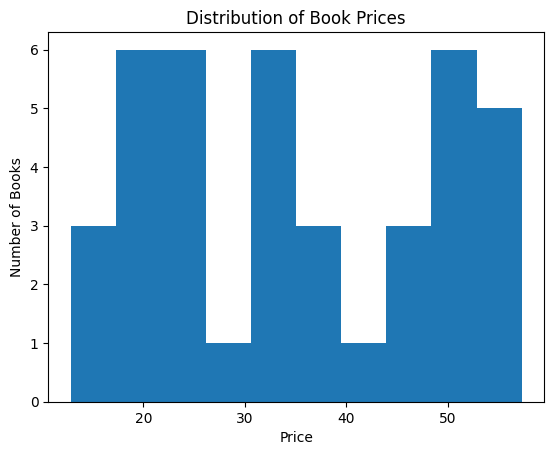

In [54]:
# check the distribution of price
import matplotlib.pyplot as plt

plt.hist(df["Price"], bins=10)
plt.xlabel("Price")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Prices")
plt.show()


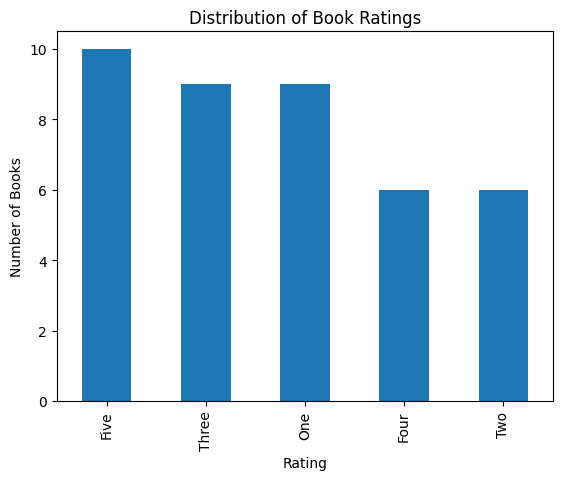

In [55]:
# visualize ratings
df["Rating"].value_counts().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Ratings")
plt.show()

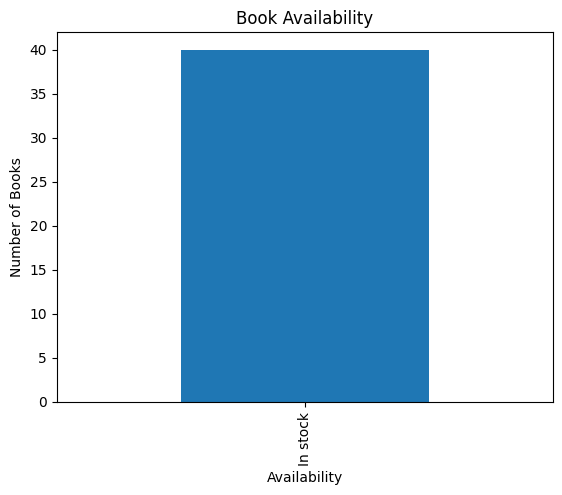

In [56]:
# visualize availability
df["Availability"].value_counts().plot(kind="bar")

plt.xlabel("Availability")
plt.ylabel("Number of Books")
plt.title("Book Availability")
plt.show()

In [57]:
# compare avg price by rating
df.groupby("Rating")["Price"].mean()

,Price
Rating,
Five,31.652000
Four,36.803333
One,34.385556
Three,39.120000
Two,33.243333


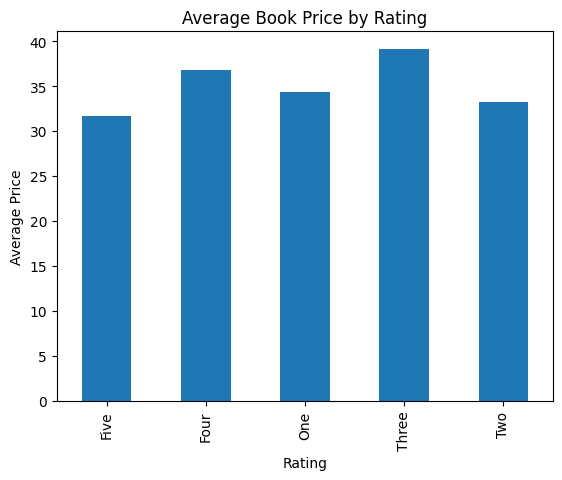

In [58]:
# visualize avg price by ratings
df.groupby("Rating")["Price"].mean().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.title("Average Book Price by Rating")
plt.show()

In [59]:
# find eda summary
print("Total Books:", len(df))
print("Average Price:", df["Price"].mean())
print("Highest Price:", df["Price"].max())
print("Lowest Price:", df["Price"].min())
print("Most Common Rating:", df["Rating"].mode()[0])
print("Most Common Availability:", df["Availability"].mode()[0])

Total Books: 40
Average Price: 34.958749999999995
Highest Price: 57.25
Lowest Price: 12.84
Most Common Rating: Five
Most Common Availability: In stock


Task-3 Data Visualization

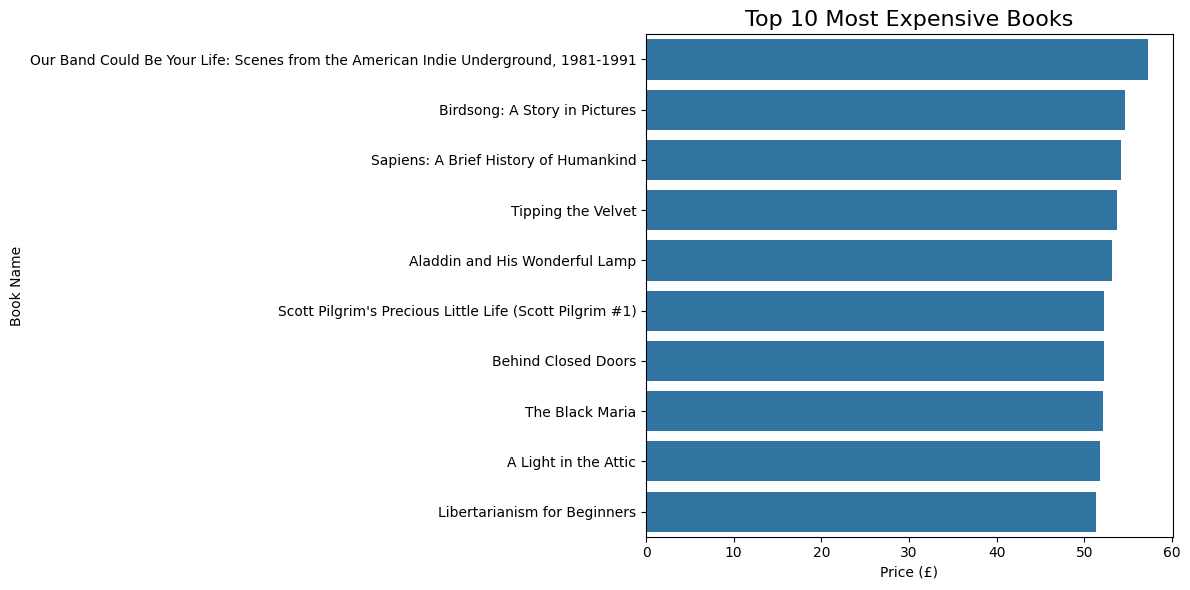

In [60]:
top10 = df.nlargest(10, "Price")
plt.figure(figsize=(12, 6))
sns.barplot(
    x="Price",
    y="Book Name",
    data=top10)
plt.title("Top 10 Most Expensive Books", fontsize=16)
plt.xlabel("Price (£)")
plt.ylabel("Book Name")
plt.tight_layout()
plt.show()

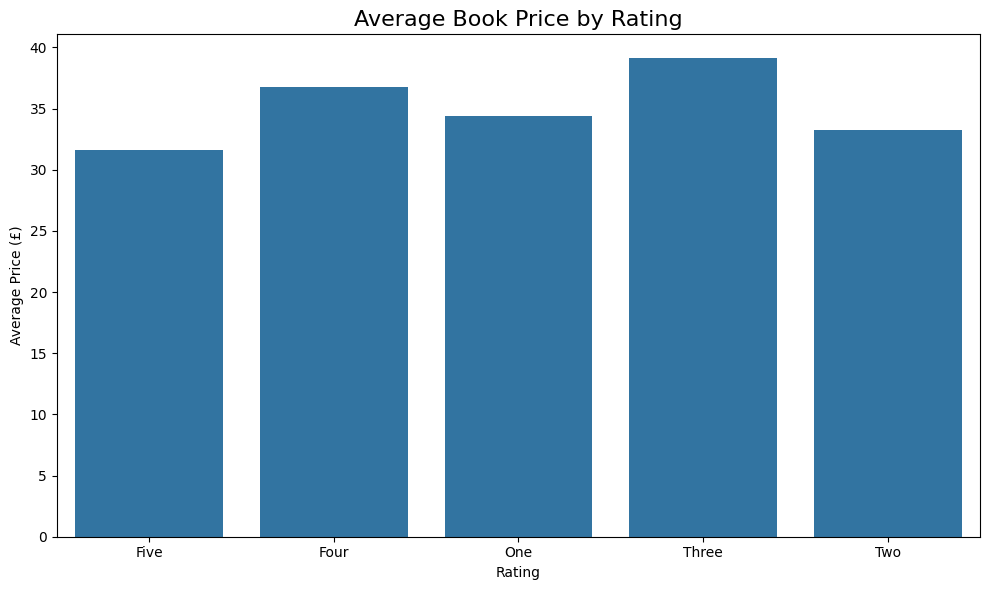

In [61]:
avg_price_rating = df.groupby("Rating")["Price"].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x="Rating",y="Price",data=avg_price_rating)
plt.title("Average Book Price by Rating", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.tight_layout()
plt.show()

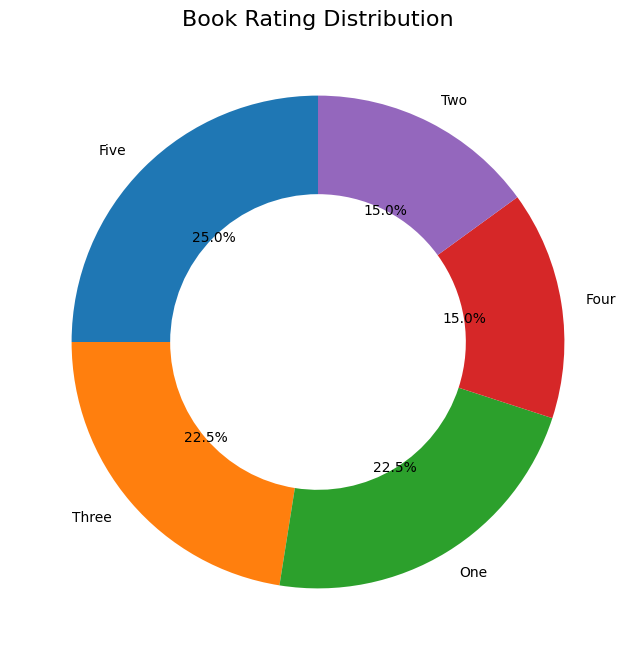

In [62]:
rating_counts = df["Rating"].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4})
plt.title("Book Rating Distribution", fontsize=16)
plt.show()

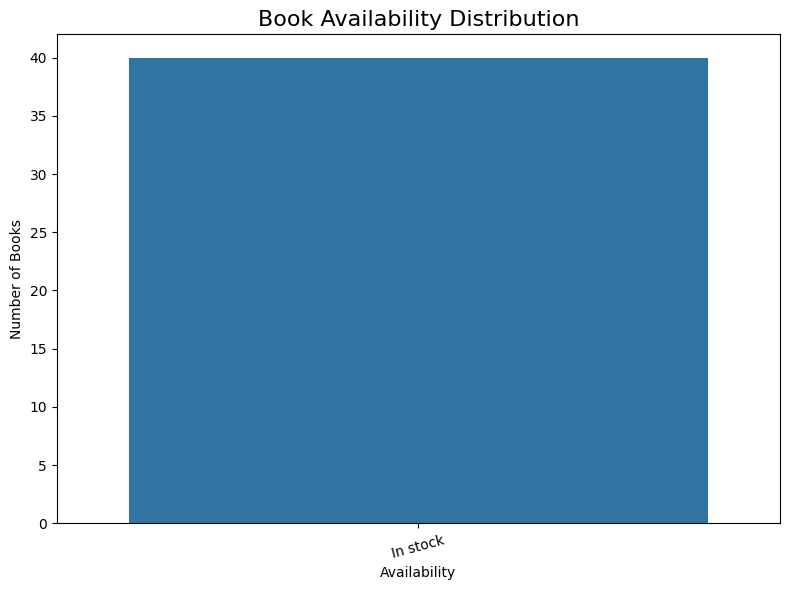

In [63]:
availability_counts = df["Availability"].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=availability_counts.index,y=availability_counts.values)
plt.title("Book Availability Distribution", fontsize=16)
plt.xlabel("Availability")
plt.ylabel("Number of Books")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

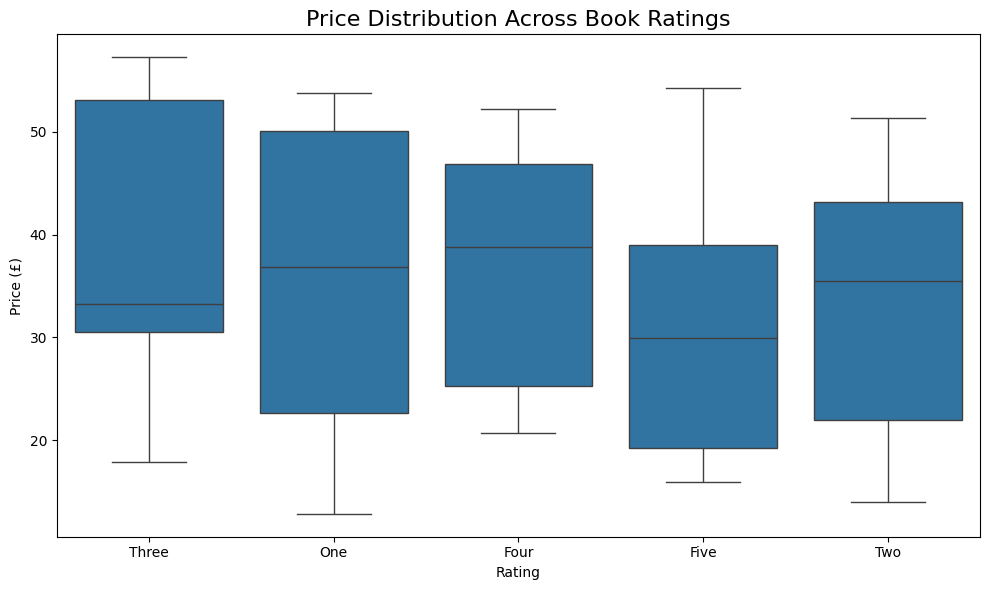

In [64]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Rating",y="Price",data=df)
plt.title("Price Distribution Across Book Ratings", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.show()

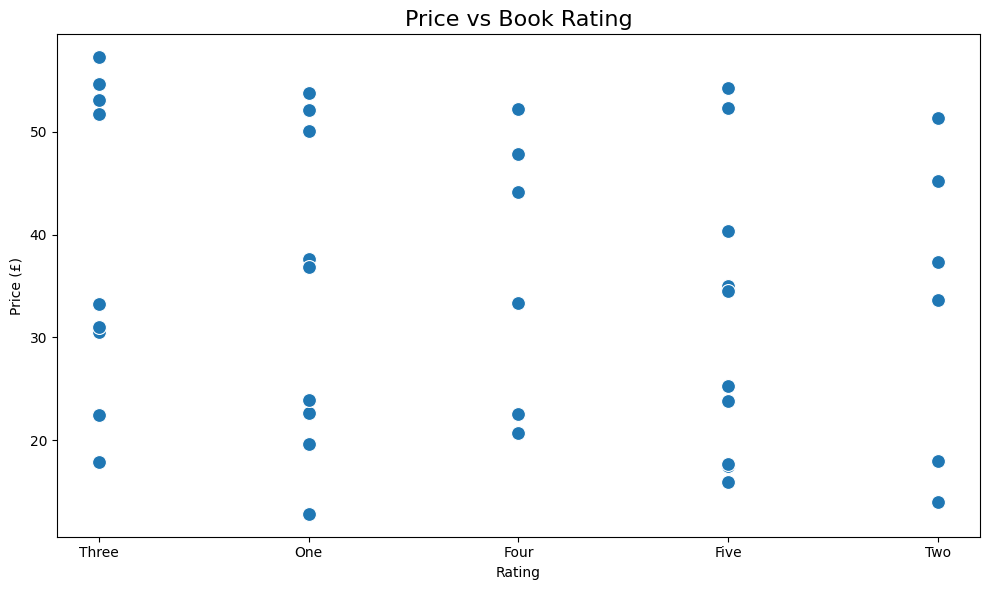

In [65]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Rating",y="Price",data=df,s=100)
plt.title("Price vs Book Rating", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.show()

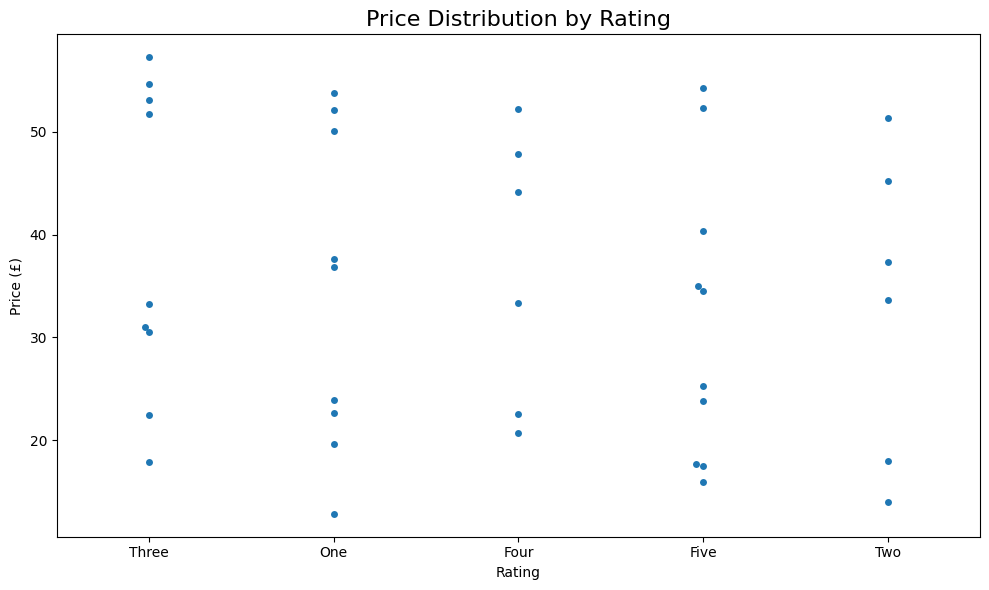

In [66]:

plt.figure(figsize=(10, 6))

sns.swarmplot(
    x="Rating",
    y="Price",
    data=df
)

plt.title("Price Distribution by Rating", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.show()

In [67]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5}
df["Rating_Num"] = df["Rating"].map(rating_map)

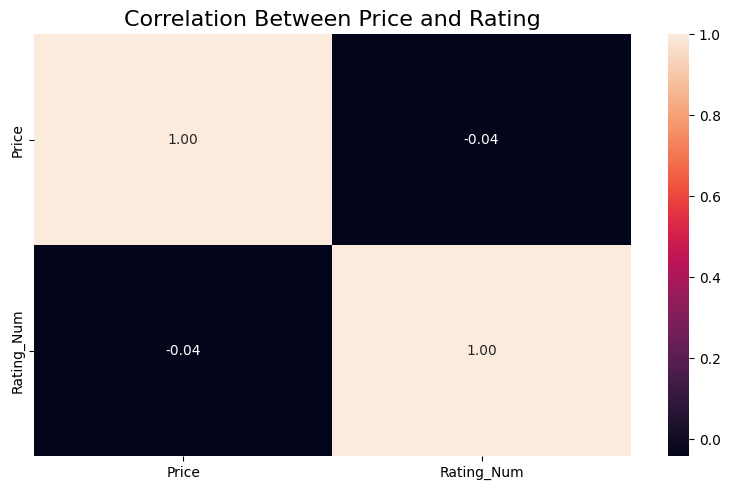

In [68]:
plt.figure(figsize=(8, 5))

corr = df[["Price", "Rating_Num"]].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f")
plt.title("Correlation Between Price and Rating", fontsize=16)
plt.tight_layout()
plt.show()

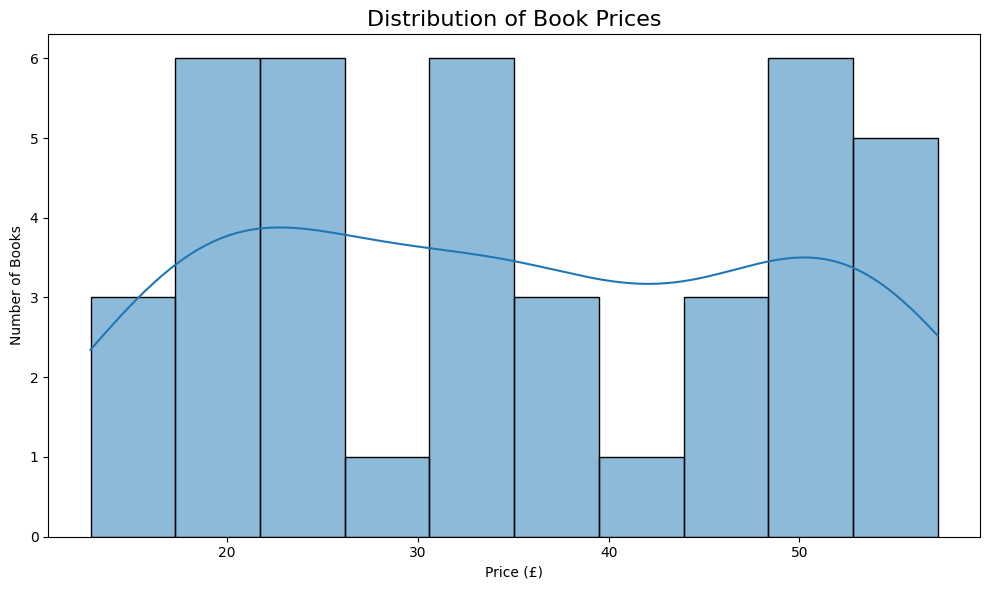

In [69]:
plt.figure(figsize=(10, 6))
sns.histplot(
    df["Price"],
    kde=True,
    bins=10)
plt.title("Distribution of Book Prices", fontsize=16)
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

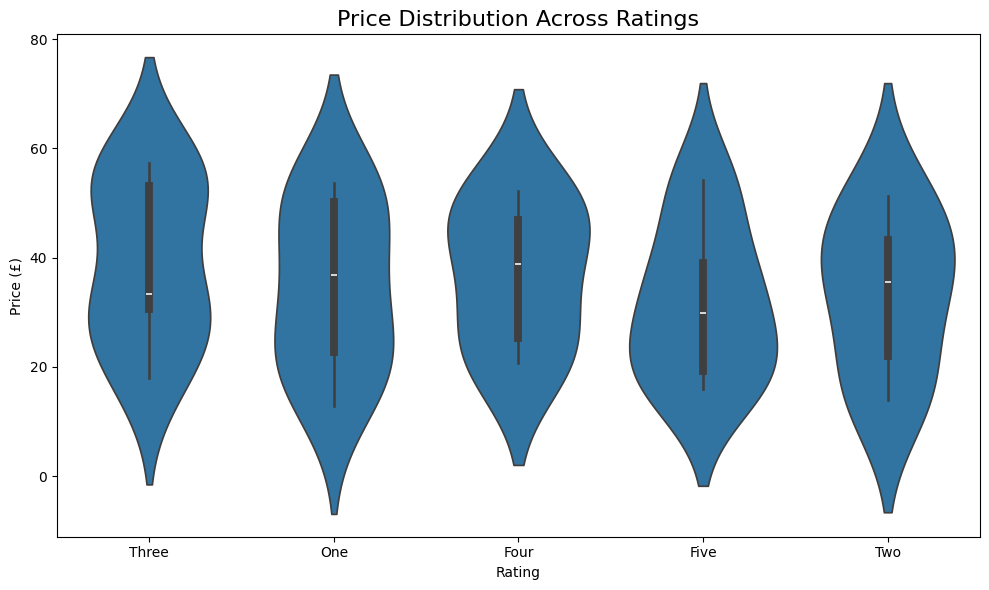

In [70]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    x="Rating",
    y="Price",
    data=df)
plt.title("Price Distribution Across Ratings", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.show()

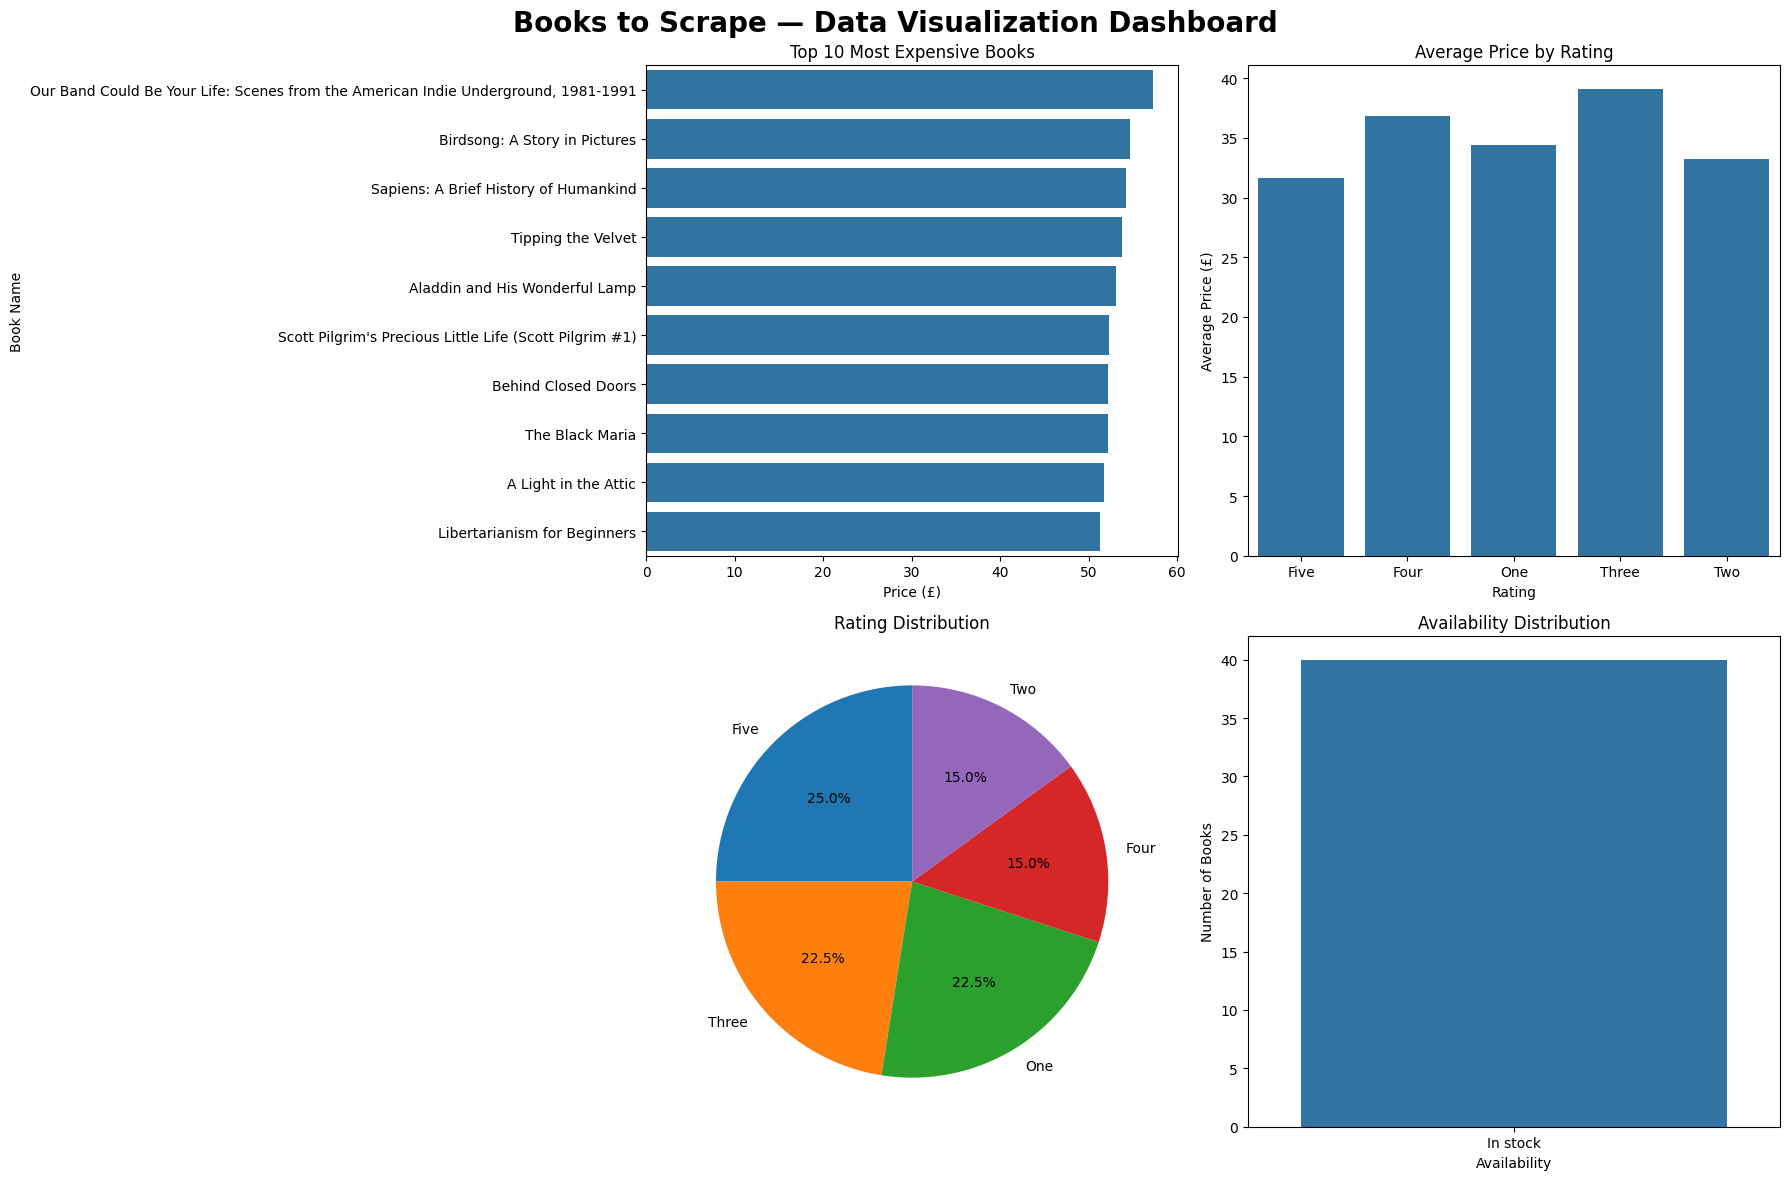

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
# 1. Top 10 Expensive Books
top10 = df.nlargest(10, "Price")
sns.barplot(
    x="Price",
    y="Book Name",
    data=top10,
    ax=axes[0, 0])
axes[0, 0].set_title("Top 10 Most Expensive Books")
axes[0, 0].set_xlabel("Price (£)")
axes[0, 0].set_ylabel("Book Name")

# 2. Average Price by Rating
avg_price_rating = df.groupby("Rating")["Price"].mean().reset_index()
sns.barplot(
    x="Rating",
    y="Price",
    data=avg_price_rating,
    ax=axes[0, 1])
axes[0, 1].set_title("Average Price by Rating")
axes[0, 1].set_xlabel("Rating")
axes[0, 1].set_ylabel("Average Price (£)")

# 3. Rating Distribution
rating_counts = df["Rating"].value_counts()
axes[1, 0].pie(
    rating_counts,
    labels=rating_counts.index,
    autopct="%1.1f%%",
    startangle=90)
axes[1, 0].set_title("Rating Distribution")


# 4. Availability Distribution
availability_counts = df["Availability"].value_counts()
sns.barplot(
    x=availability_counts.index,
    y=availability_counts.values,
    ax=axes[1, 1])
axes[1, 1].set_title("Availability Distribution")
axes[1, 1].set_xlabel("Availability")
axes[1, 1].set_ylabel("Number of Books")
plt.suptitle(
    "Books to Scrape — Data Visualization Dashboard",
    fontsize=20,
    fontweight="bold")
plt.tight_layout()
plt.show()

In [72]:
fig.savefig(
    "books_visualization_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

In [73]:
print("===== FINAL VISUALIZATION SUMMARY =====")

print("\nTop 5 Most Expensive Books:")
print(df.nlargest(5, "Price")[["Book Name", "Price"]])

print("\nAverage Price by Rating:")
print(df.groupby("Rating")["Price"].mean().round(2))

print("\nRating Distribution:")
print(df["Rating"].value_counts())

print("\nAvailability Distribution:")
print(df["Availability"].value_counts())

print("\nPrice-Rating Correlation:")
print(df[["Price", "Rating_Num"]].corr().round(2))

===== FINAL VISUALIZATION SUMMARY =====

Top 5 Most Expensive Books:
                                            Book Name  Price
15  Our Band Could Be Your Life: Scenes from the A...  57.25
25                      Birdsong: A Story in Pictures  54.64
4               Sapiens: A Brief History of Humankind  54.23
1                                  Tipping the Velvet  53.74
27                     Aladdin and His Wonderful Lamp  53.13

Average Price by Rating:
Rating
Five     31.65
Four     36.80
One      34.39
Three    39.12
Two      33.24
Name: Price, dtype: float64

Rating Distribution:
Rating
Five     10
Three     9
One       9
Four      6
Two       6
Name: count, dtype: int64

Availability Distribution:
Availability
In stock    40
Name: count, dtype: int64

Price-Rating Correlation:
            Price  Rating_Num
Price        1.00       -0.04
Rating_Num  -0.04        1.00


In [74]:
print("Final dataset saved successfully!")
print("Shape:", df.shape)

Final dataset saved successfully!
Shape: (40, 5)
